# Figure: Tissue-specific pathway retention (engine-native)

This notebook regenerates the tissue-specific pathway-retention heatmap directly
from `ExposoGraph.engine.GraphEngine`, using the domain-specific getters added to
the engine (`get_tissues`, `get_carcinogen_groups`, `carcinogens_by_group`) instead
of a hand-maintained tissue list / carcinogen-class mapping. It's a tighter,
graph-native companion to `Figure-2-tissue-specific-pathway-retention.ipynb`,
**not** a drop-in replacement that reproduces identical numbers -- see the
"How this compares to Figure 2" section below for the methodological differences
and why they change the resulting values.

In [7]:
from __future__ import annotations
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
from ExposoGraph.engine import GraphEngine

## 1. Instantiate the knowledge graph via `engine.py`

Uses `GraphEngine.load_reference_graph()` directly -- the same canonical loading
path (bundled `graph-data.json` + tissue expression + interaction parameters)
that the rest of the package relies on.

In [8]:
engine = GraphEngine()
load_warnings = engine.load_reference_graph()
if load_warnings:
    print(f"\n{len(load_warnings)} load warning(s):")
    for warning in load_warnings:
        print(f"  - {warning}")


1 load warning(s):
  - No tissue expression data for enzyme: GSTT1


In [ ]:
TISSUES = engine.get_tissues()
print(f"{len(TISSUES)} tissues")
CARCINOGEN_CATEGORIES = engine.get_carcinogen_groups()
print(f"{len(CARCINOGEN_CATEGORIES)} carcinogen categories")

10 tissues:
21 carcinogen categories:


## 4. Retention ratio

For each (carcinogen category, tissue) cell:

- **Denominator** -- the number of graph edges whose `carcinogen` field names a
  `Carcinogen` node in that category (see point 4 in the comparison above).
- **Numerator** -- the subset of those edges where at least one endpoint
  (source or target) is an `Enzyme` node with
  `tissue_weights[tissue] >= TISSUE_WEIGHT_THRESHOLD`.
- **Cell value** = `100 * numerator / denominator`, or `NaN` (shown as `n/a`) if
  the category has zero edges in the graph at all.

`TISSUE_WEIGHT_THRESHOLD` is on the engine's normalized 0-1 `tissue_weights`
scale -- see comparison point 2 above before treating this as equivalent to the
old notebook's raw-nTPM `0.25` cutoff.

In [12]:
TISSUE_WEIGHT_THRESHOLD = 0.25

node_data = dict(engine.G.nodes(data=True))
edges = [(u, v, data) for u, v, data in engine.G.edges(data=True)]

category_carcinogen_ids = {
    category: {node["id"] for node in engine.carcinogens_by_group(category)}
    for category in CARCINOGEN_CATEGORIES
}


def enzyme_meets_threshold(node_id: str, tissue: str, threshold: float) -> bool:
    data = node_data.get(node_id)
    if data is None or data.get("type") != "Enzyme":
        return False
    weights = data.get("tissue_weights")
    if not weights:
        return False
    return weights.get(tissue, float("-inf")) >= threshold


rows: list[list[float]] = []
denominators: dict[str, int] = {}

for category in CARCINOGEN_CATEGORIES:
    carcinogen_ids = category_carcinogen_ids[category]
    category_edges = [
        (u, v, data) for u, v, data in edges if data.get("carcinogen") in carcinogen_ids
    ]
    denominators[category] = len(category_edges)

    row: list[float] = []
    for tissue in TISSUES:
        if not category_edges:
            row.append(np.nan)
            continue
        numerator = sum(
            1
            for u, v, _ in category_edges
            if enzyme_meets_threshold(u, tissue, TISSUE_WEIGHT_THRESHOLD)
            or enzyme_meets_threshold(v, tissue, TISSUE_WEIGHT_THRESHOLD)
        )
        row.append(100.0 * numerator / len(category_edges))
    rows.append(row)

retention = pd.DataFrame(rows, index=CARCINOGEN_CATEGORIES, columns=TISSUES)


## 5. Heatmap

Seaborn heatmap with a blue/red diverging colormap (`RdBu_r`: low retention ->
blue, high retention -> red), centered at 50%. Categories with no graph edges at
all are masked and annotated `n/a`. Not saved to disk -- rendered inline only.

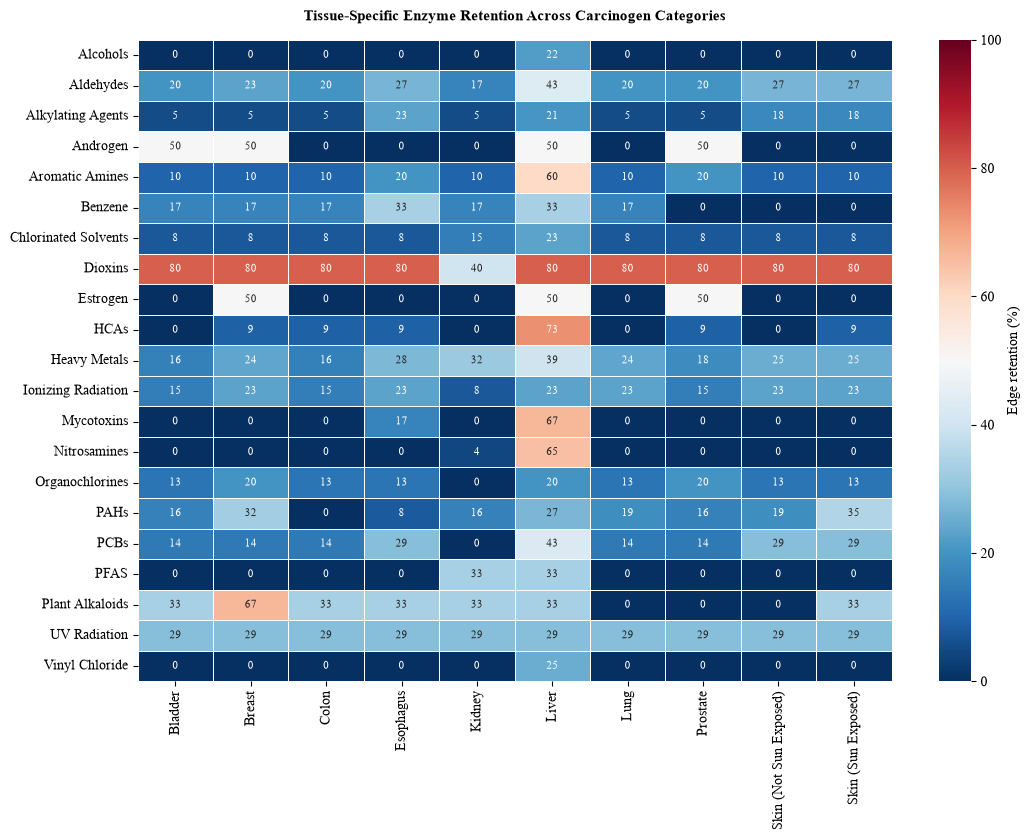

In [ ]:
fig, ax = plt.subplots(figsize=(11, 8.5))

mask = retention.isna()
sns.heatmap(
    retention,
    ax=ax,
    cmap="RdBu_r",
    vmin=0,
    vmax=100,
    center=50,
    mask=mask,
    annot=True,
    fmt=".0f",
    annot_kws={"fontsize": 8},
    linewidths=0.5,
    linecolor="white",
    square=False,
    cbar_kws={"label": "Edge retention (%)"},
)
ax.set_facecolor("#e8e8e8")

for row_idx, category in enumerate(CARCINOGEN_CATEGORIES):
    if denominators[category] == 0:
        for col_idx in range(len(TISSUES)):
            ax.text(
                col_idx,
                row_idx,
                "n/a",
                ha="center",
                va="center",
                fontsize=8,
                color="#666666",
            )

ax.set_title(
    "Tissue-Specific Enzyme Retention Across Carcinogen Categories",
    fontsize=11,
    weight="bold",
    pad=14,
)
plt.setp(ax.get_xticklabels(), rotation=90) 
fig.tight_layout()
plt.show()

In [17]:
retention.mean(axis=1)

Alcohols                 2.222222
Aldehydes               24.333333
Alkylating Agents       11.025641
Androgen                20.000000
Aromatic Amines         17.000000
Benzene                 15.000000
Chlorinated Solvents    10.000000
Dioxins                 76.000000
Estrogen                15.000000
HCAs                    11.818182
Heavy Metals            24.605263
Ionizing Radiation      19.230769
Mycotoxins               8.333333
Nitrosamines             6.956522
Organochlorines         14.000000
PAHs                    18.918919
PCBs                    20.000000
PFAS                     6.666667
Plant Alkaloids         26.666667
UV Radiation            28.571429
Vinyl Chloride           2.500000
dtype: float64